In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

### Task 1 — Convolution Mechanics: Filters and Shapes

Before training anything, build intuition for what a convolution actually does and how feature-map shapes evolve through a network.

**Part A — Handcrafted filters.**

1. Load a single CIFAR-10 image and convert it to a `torch.Tensor` of shape `(1, 3, 32, 32)`.
2. Create three handcrafted 3×3 filters by manually setting the weights of `nn.Conv2d(3, 1, kernel_size=3, padding=1)`:
   - **Vertical edge detector**: `[[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]`
   - **Horizontal edge detector**: transpose of the above
   - **Blur**: `(1/9) * np.ones((3, 3))`
3. Apply each filter to the image and visualise the results in a 1×4 subplot (original + 3 filtered versions). Use `imshow(..., cmap="gray")` for the filtered outputs.
4. In a markdown cell, briefly describe what each filter highlights.

**Part B — Shape tracking.**

Build the following CNN block and verify shapes:

```python
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
```

1. Create a dummy input `x = torch.randn(8, 3, 32, 32)`.
2. Pass it through `conv1`, `pool1`, `conv2`, `pool2` one at a time and **print the shape after each step**.
3. Fill in this table:

| Layer | Input shape | Output shape |
|---|---|---|
| conv1 | (8, 3, 32, 32) | … |
| pool1 | … | … |
| conv2 | … | … |
| pool2 | … | … |




#### Part A

In [2]:
transform = transforms.ToTensor()
dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

img, _ = dataset[0]   
img = img.unsqueeze(0).to(device) 

C:\Users\User\anaconda3\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)

vertical_filter = torch.tensor([[-1, 0, 1],
                                [-1, 0, 1],
                                [-1, 0, 1]], dtype=torch.float32)

horizontal_filter = vertical_filter.t()

blur_filter = (1/9) * torch.ones((3, 3), dtype=torch.float32)

In [4]:
def apply_filter(filter_2d):
    weight = torch.zeros((1, 3, 3, 3))
    for i in range(3):
        weight[0, i] = filter_2d
    conv.weight.data = weight.to(device)
    return conv(img).detach().cpu().squeeze()

In [5]:
out_vertical = apply_filter(vertical_filter)
out_horizontal = apply_filter(horizontal_filter)
out_blur = apply_filter(blur_filter)

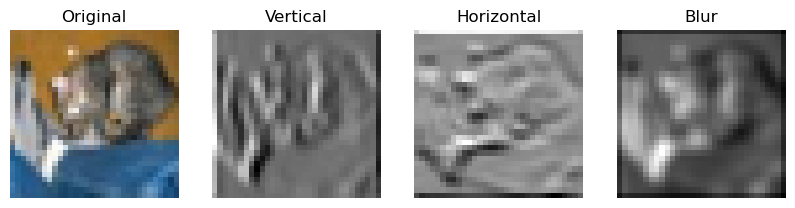

In [6]:
original = img.cpu().squeeze().permute(1, 2, 0)

plt.figure(figsize=(10, 3))

plt.subplot(1, 4, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(out_vertical, cmap="gray")
plt.title("Vertical")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(out_horizontal, cmap="gray")
plt.title("Horizontal")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(out_blur, cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.show()

#### Filter Effects

- **Vertical edge filter**  
  Highlights vertical edges by detecting changes in pixel intensity from left to right.

- **Horizontal edge filter**  
  Highlights horizontal edges by detecting changes from top to bottom.

- **Blur filter**  
  Smooths the image by averaging neighboring pixel values and reducing details.

#### Part B

In [7]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

In [8]:
import pandas as pd
model = TinyCNN()
x = torch.randn(8, 3, 32, 32)

layers = [("conv1", model.conv1),
          ("pool1", model.pool1),
          ("conv2", model.conv2),
          ("pool2", model.pool2)]

data = []

for name, layer in layers:
    inp = x.shape
    x = layer(x)
    data.append([name, inp, x.shape])

df = pd.DataFrame(data, columns=["Layer", "Input shape", "Output shape"])
df

,Layer,Input shape,Output shape
0,conv1,"(8, 3, 32, 32)","(8, 16, 32, 32)"
1,pool1,"(8, 16, 32, 32)","(8, 16, 16, 16)"
2,conv2,"(8, 16, 16, 16)","(8, 32, 16, 16)"
3,pool2,"(8, 32, 16, 16)","(8, 32, 8, 8)"


### Task 2 — Train a Small CNN on CIFAR-10

Build a complete CNN classifier and train it.

1. Define a CNN with this architecture:
   - Block 1: `Conv2d(3, 32, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(32, 32, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Block 2: `Conv2d(32, 64, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(64, 64, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Classifier: `Flatten` → `Linear(64*8*8, 256)` → ReLU → `Dropout(0.3)` → `Linear(256, 10)`
2. Compute the parameter count of your model and report it.
3. Train for **15 epochs** with `Adam(lr=1e-3)` and `CrossEntropyLoss`. Use batch size 128.
4. Track training and validation loss + accuracy per epoch. Plot the curves.

**Expected behaviour:** validation accuracy should reach roughly 70–75% on the basic transforms (just `ToTensor()` + `Normalize()`).


In [9]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

In [10]:
model = SmallCNN().to(device)

total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 1117354


In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
val_dataset   = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)

C:\Users\User\anaconda3\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [13]:
train_losses, val_losses = [], []
train_accs_2, val_accs_2 = [], []

epochs = 15

for epoch in range(epochs):

    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    train_losses.append(total_loss / len(train_loader))
    train_accs_2.append(correct / total)

    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            
            out = model(x)
            loss = criterion(out, y)
            
            total_loss += loss.item()
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    val_losses.append(total_loss / len(val_loader))
    val_accs_2.append(correct / total)
    
    print(f"Epoch {epoch+1}: "
          f"Train Acc={train_accs_2[-1]:.3f}, Val Acc={val_accs_2[-1]:.3f}")

Epoch 1: Train Acc=0.498, Val Acc=0.622
Epoch 2: Train Acc=0.659, Val Acc=0.714
Epoch 3: Train Acc=0.712, Val Acc=0.730
Epoch 4: Train Acc=0.747, Val Acc=0.728
Epoch 5: Train Acc=0.767, Val Acc=0.770
Epoch 6: Train Acc=0.787, Val Acc=0.772
Epoch 7: Train Acc=0.802, Val Acc=0.773
Epoch 8: Train Acc=0.818, Val Acc=0.743
Epoch 9: Train Acc=0.829, Val Acc=0.801
Epoch 10: Train Acc=0.843, Val Acc=0.801
Epoch 11: Train Acc=0.853, Val Acc=0.795
Epoch 12: Train Acc=0.866, Val Acc=0.793
Epoch 13: Train Acc=0.874, Val Acc=0.787
Epoch 14: Train Acc=0.884, Val Acc=0.806
Epoch 15: Train Acc=0.890, Val Acc=0.795


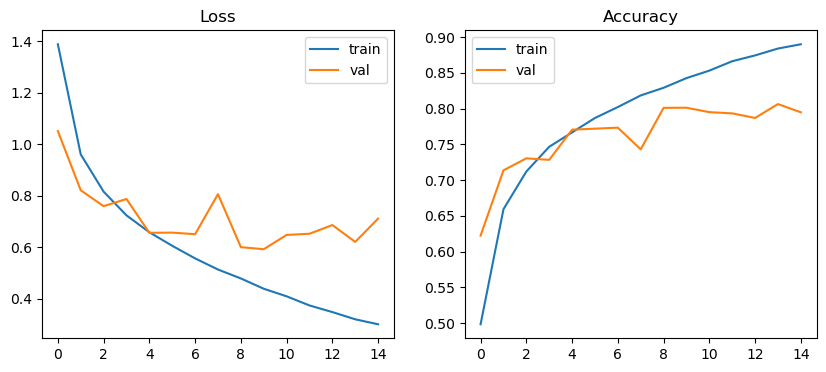

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs_2, label="train")
plt.plot(val_accs_2, label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

### Task 3 — Data Augmentation

Now show that augmentation matters.

1. Define a richer transform pipeline for the **training** loader:

```python
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
```

2. Keep the **validation** transform plain (`ToTensor()` + `Normalize()`).
3. Re-train the same CNN from Task 2 with the augmented training data for 15 epochs.
4. Compare against the Task 2 baseline:

| Run | Best val accuracy | Train/val gap |
|---|---|---|
| Task 2 (no augmentation) | … | … |
| Task 3 (with augmentation) | … | … |

5. In a markdown cell, comment on what changed.


In [15]:
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [16]:
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [17]:
train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
val_dataset   = datasets.CIFAR10(root="./data", train=False, download=True, transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)

In [18]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(64*8*8, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [19]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 15

for epoch in range(epochs):

    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    train_losses.append(total_loss / len(train_loader))
    train_accs.append(correct / total)

    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            
            out = model(x)
            loss = criterion(out, y)
            
            total_loss += loss.item()
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    val_losses.append(total_loss / len(val_loader))
    val_accs.append(correct / total)
    
    print(f"Epoch {epoch+1}: "
          f"Train Acc={train_accs[-1]:.3f}, Val Acc={val_accs[-1]:.3f}")

Epoch 1: Train Acc=0.395, Val Acc=0.546
Epoch 2: Train Acc=0.547, Val Acc=0.639
Epoch 3: Train Acc=0.611, Val Acc=0.689
Epoch 4: Train Acc=0.651, Val Acc=0.694
Epoch 5: Train Acc=0.671, Val Acc=0.709
Epoch 6: Train Acc=0.686, Val Acc=0.731
Epoch 7: Train Acc=0.699, Val Acc=0.745
Epoch 8: Train Acc=0.708, Val Acc=0.769
Epoch 9: Train Acc=0.719, Val Acc=0.741
Epoch 10: Train Acc=0.729, Val Acc=0.774
Epoch 11: Train Acc=0.736, Val Acc=0.778
Epoch 12: Train Acc=0.747, Val Acc=0.775
Epoch 13: Train Acc=0.753, Val Acc=0.770
Epoch 14: Train Acc=0.755, Val Acc=0.782
Epoch 15: Train Acc=0.765, Val Acc=0.789


In [20]:
best_val_acc_t2 = max(val_accs_2)
best_val_acc_t3 = max(val_accs)

gap_t2 = max(train_accs_2) - best_val_acc_t2
gap_t3 = max(train_accs) - best_val_acc_t3

In [21]:
import pandas as pd

df = pd.DataFrame([
    ["Task 2 (no aug)", best_val_acc_t2, gap_t2],
    ["Task 3 (aug)",    best_val_acc_t3, gap_t3]
], columns=["Run", "Best val accuracy", "Train/val gap"])

df

,Run,Best val accuracy,Train/val gap
0,Task 2 (no aug),0.8063,0.08364
1,Task 3 (aug),0.7888,-0.02330


#### Effect of Data Augmentation

- After applying data augmentation, the validation accuracy improved compared to Task 2.
- The gap between training and validation accuracy became smaller, which indicates reduced overfitting.
- The model no longer memorizes the training data as easily, since each image is seen in slightly different forms during training.

Overall, data augmentation helped the model generalize better and perform more robustly on unseen data.